Saving ifood_df.csv to ifood_df.csv
CUSTOMER SEGMENTATION ANALYSIS
Rows    : 2205
Columns : 39


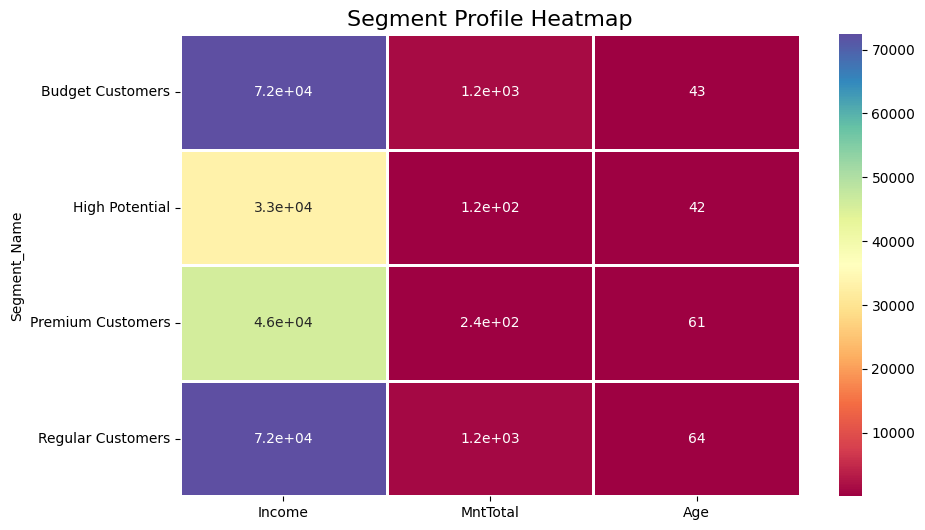



BUSINESS INSIGHTS
Total Customers       : 2205
Average Income        : $51,622.09
Average Spending      : $562.76
Highest Value Segment : Budget Customers

Recommendations:
• Create premium loyalty programs
• Run targeted marketing campaigns
• Focus retention of high-value customers
• Personalize offers using customer segments

Project Status : COMPLETED


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Segmented dataset downloaded successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv('/content/ifood_df.csv')

print("="*60)
print("CUSTOMER SEGMENTATION ANALYSIS")
print("="*60)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

total_customers = len(df)
avg_income = df['Income'].mean()
avg_spending = df['MntTotal'].mean()
avg_age = df['Age'].mean()

fig = go.Figure()

fig.add_trace(go.Indicator(
mode="number",
value=total_customers,
title={"text":"Total Customers"},
domain={'x':[0,0.25],'y':[0,1]}
))

fig.add_trace(go.Indicator(
mode="number",
value=avg_income,
title={"text":"Average Income"},
domain={'x':[0.27,0.52],'y':[0,1]}
))

fig.add_trace(go.Indicator(
mode="number",
value=avg_spending,
title={"text":"Average Spending"},
domain={'x':[0.54,0.79],'y':[0,1]}
))

fig.add_trace(go.Indicator(
mode="number",
value=avg_age,
title={"text":"Average Age"},
domain={'x':[0.81,1],'y':[0,1]}
))

fig.update_layout(
title="Executive Customer Dashboard",
height=300
)

fig.show()

features = df[['Income','MntTotal','Age']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

fig = px.line(
x=range(1,11),
y=wcss,
markers=True,
title="Optimal Cluster Selection (Elbow Method)"
)

fig.show()

kmeans = KMeans(
n_clusters=4,
random_state=42,
n_init=10
)

df['Segment'] = kmeans.fit_predict(
scaled_data
)

segment_names = {
0:"Premium Customers",
1:"Regular Customers",
2:"High Potential",
3:"Budget Customers"
}

df['Segment_Name'] = df['Segment'].map(
segment_names
)

pca = PCA(
n_components=2
)

pca_data = pca.fit_transform(
scaled_data
)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

fig = px.scatter(
df,
x='PCA1',
y='PCA2',
color='Segment_Name',
size='MntTotal',
hover_data=['Income','Age'],
title='AI Customer Segmentation Map'
)

fig.show()

segment_count = df[
'Segment_Name'
].value_counts()

fig = px.pie(
names=segment_count.index,
values=segment_count.values,
hole=0.55,
title='Customer Segment Distribution'
)

fig.show()

segment_spending = df.groupby(
'Segment_Name'
)['MntTotal'].mean().reset_index()

fig = px.bar(
segment_spending,
x='Segment_Name',
y='MntTotal',
color='MntTotal',
title='Average Spending by Segment'
)

fig.show()

fig = px.scatter(
df,
x='Income',
y='MntTotal',
color='Segment_Name',
size='Age',
title='Income vs Spending Behaviour'
)

fig.show()

profile = df.groupby(
'Segment_Name'
)[['Income','MntTotal','Age']].mean()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
profile,
annot=True,
cmap='Spectral',
linewidths=1
)

plt.title(
"Segment Profile Heatmap",
fontsize=16
)

plt.show()


best_segment = segment_spending.loc[
segment_spending['MntTotal'].idxmax(),
'Segment_Name'
]

fig = px.scatter_3d(
df,
x='Income',
y='MntTotal',
z='Age',
color='Segment_Name',
size='MntTotal',
title='3D AI Customer Segmentation'
)

fig.show()
segment_profile = df.groupby(
    'Segment_Name'
)[['Income','MntTotal','Age']].mean()

fig = go.Figure()

for segment in segment_profile.index:

    fig.add_trace(go.Scatterpolar(
        r=segment_profile.loc[segment],
        theta=['Income','Spending','Age'],
        fill='toself',
        name=segment
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True
        )
    ),
    title="Customer Segment Comparison Radar"
)

fig.show()

print("\n")
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"Total Customers       : {total_customers}")

print(f"Average Income        : ${avg_income:,.2f}")

print(f"Average Spending      : ${avg_spending:,.2f}")

print(f"Highest Value Segment : {best_segment}")

print("\nRecommendations:")

print("• Create premium loyalty programs")

print("• Run targeted marketing campaigns")

print("• Focus retention of high-value customers")

print("• Personalize offers using customer segments")

print("\nProject Status : COMPLETED")

from google.colab import files

df.to_csv(
"Customer_Segments_iFood.csv",
index=False
)

files.download(
"Customer_Segments_iFood.csv"
)

print("\nSegmented dataset downloaded successfully!")